# Parameter identification, sensitivity, and uncertainty

This notebook formulates and verifies a constitutive inverse problem
for a homogeneous two-family soft tissue.

The workflow is

\[
\text{synthetic loading protocols}
\rightarrow
\text{noisy stress observations}
\rightarrow
\text{sensitivity and identifiability}
\rightarrow
\text{parameter estimation}
\rightarrow
\text{uncertainty intervals}.
\]

The benchmark data are synthetic. Known ground truth permits direct checks of recovery accuracy and interval coverage.

## Objectives

1. demonstrate why \(\kappa\) cannot be identified from isochoric tests;
2. restore full local rank with a small dilation protocol;
3. recover six positive material parameters by weighted least squares;
4. inspect parameter correlation and conditioning;
5. estimate uncertainty from the local Jacobian and a parametric bootstrap;
6. export all observations, estimates, sensitivities, and bootstrap samples.

In [20]:
from __future__ import annotations

import csv
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (
    MaterialParameterMap,
    MultiFiberMaterialParameters,
    angle_to_vector,
    build_multiaxial_protocol_dataset,
    fit_material_parameters,
    local_sensitivity_matrix,
    parametric_bootstrap_material_fit,
    predict_dataset_stress,
)

np.set_printoptions(precision=6, suppress=True)

print(f"Repository root: {REPOSITORY_ROOT}")
print(f"NumPy version: {np.__version__}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
NumPy version: 1.24.3


## 1. Known synthetic tissue and parameter vector

The reference tissue has two undirected fiber families:

\[
\alpha_1=18^\circ,\qquad
\alpha_2=102^\circ,
\]

with known structural-order values and mixture weights. The fitted
parameter vector is

\[
\mathbf p=
(\mu,k_{11},k_{12},k_{21},k_{22},\kappa).
\]

The fiber architecture is held fixed in this notebook. Uncertainty
in image-derived orientation and structural order is therefore not
yet included.

In [21]:
fiber_direction = angle_to_vector(np.deg2rad([18.0, 102.0]))
structural_order = np.array([0.78, 0.46])

true_material = MultiFiberMaterialParameters(
    mu=2.4,
    kappa=180.0,
    k1=(3.2, 1.7),
    k2=(4.6, 3.4),
    family_weights=(0.65, 0.35),
)

parameter_map = MaterialParameterMap(
    number_of_families=2,
    family_weights=true_material.family_weights,
    identify_kappa=True,
)
true_parameters = parameter_map.pack(true_material)

print(f"{'parameter':>12} {'true value':>14}")
for name, value in zip(
    parameter_map.parameter_names,
    true_parameters,
    strict=True,
):
    print(f"{name:>12} {value:14.6f}")

   parameter     true value
          mu       2.400000
        k1_1       3.200000
        k1_2       1.700000
        k2_1       4.600000
        k2_2       3.400000
       kappa     180.000000


## 2. Loading-protocol design benchmark

Three protocols preserve area:

\[
\mathbf F_x=
\begin{bmatrix}
\lambda&0\\0&\lambda^{-1}
\end{bmatrix},
\qquad
\mathbf F_y=
\begin{bmatrix}
\lambda^{-1}&0\\0&\lambda
\end{bmatrix},
\qquad
\mathbf F_s=
\begin{bmatrix}
1&\gamma\\0&1
\end{bmatrix}.
\]

Therefore, \(J=1\) in every observation. A fourth protocol introduces
a small isotropic dilation,

\[
\mathbf F_d=s\mathbf I,
\]

to provide information about the volumetric penalty.

In [22]:
axial_stretches = np.linspace(1.0, 1.18, 13)
shear_values = np.linspace(0.0, 0.20, 11)
dilation_values = np.linspace(1.0, 1.018, 9)

isochoric_dataset = build_multiaxial_protocol_dataset(
    true_material,
    fiber_direction,
    structural_order,
    axial_stretches=axial_stretches,
    shear_values=shear_values,
    dilation_values=None,
    relative_noise=0.015,
    absolute_noise=0.003,
    random_seed=2026,
)

augmented_dataset = build_multiaxial_protocol_dataset(
    true_material,
    fiber_direction,
    structural_order,
    axial_stretches=axial_stretches,
    shear_values=shear_values,
    dilation_values=dilation_values,
    relative_noise=0.015,
    absolute_noise=0.003,
    random_seed=2026,
)

print(f"Isochoric observations: {isochoric_dataset.number_of_observations}")
print(f"Augmented observations: {augmented_dataset.number_of_observations}")
print(f"Protocols: {augmented_dataset.protocols}")

Isochoric observations: 37
Augmented observations: 46
Protocols: ('uniaxial_x', 'uniaxial_y', 'simple_shear', 'dilation')


## 3. Local sensitivity and structural identifiability

In [23]:
sensitivity_isochoric = local_sensitivity_matrix(
    isochoric_dataset,
    fiber_direction,
    structural_order,
    true_material,
    parameter_map,
)
sensitivity_augmented = local_sensitivity_matrix(
    augmented_dataset,
    fiber_direction,
    structural_order,
    true_material,
    parameter_map,
)

weighted_log_sensitivity_isochoric = (
    sensitivity_isochoric
    * true_parameters[None, :]
    / isochoric_dataset.noise_std[:, None]
)
weighted_log_sensitivity_augmented = (
    sensitivity_augmented
    * true_parameters[None, :]
    / augmented_dataset.noise_std[:, None]
)

singular_isochoric = np.linalg.svd(
    weighted_log_sensitivity_isochoric,
    compute_uv=False,
)
singular_augmented = np.linalg.svd(
    weighted_log_sensitivity_augmented,
    compute_uv=False,
)

rank_isochoric = np.linalg.matrix_rank(
    weighted_log_sensitivity_isochoric,
    tol=singular_isochoric[0] * 1.0e-10,
)
rank_augmented = np.linalg.matrix_rank(
    weighted_log_sensitivity_augmented,
    tol=singular_augmented[0] * 1.0e-10,
)

print(f"Isochoric rank: {rank_isochoric} / {parameter_map.size}")
print(f"Augmented rank: {rank_augmented} / {parameter_map.size}")
print(
    "Norm of the isochoric kappa-sensitivity column: "
    f"{np.linalg.norm(sensitivity_isochoric[:, -1]):.3e}"
)
print(
    "Norm of the augmented kappa-sensitivity column: "
    f"{np.linalg.norm(sensitivity_augmented[:, -1]):.3e}"
)

assert rank_isochoric == parameter_map.size - 1
assert rank_augmented == parameter_map.size
assert np.allclose(sensitivity_isochoric[:, -1], 0.0, atol=1.0e-10)

Isochoric rank: 5 / 6
Augmented rank: 6 / 6
Norm of the isochoric kappa-sensitivity column: 0.000e+00
Norm of the augmented kappa-sensitivity column: 6.204e-02


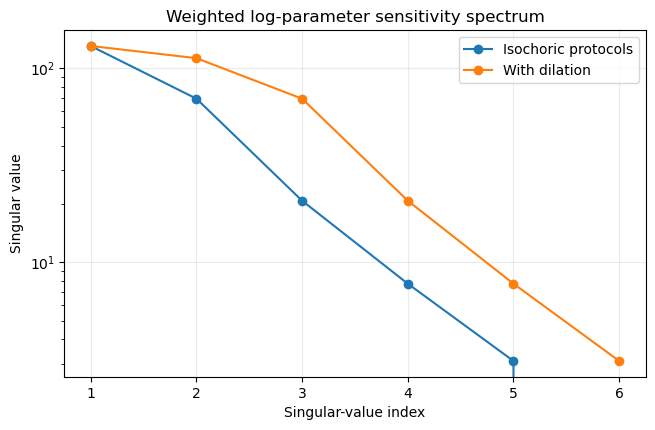

In [24]:
figure, axis = plt.subplots(figsize=(7.5, 4.5))
index = np.arange(1, parameter_map.size + 1)
axis.semilogy(index, singular_isochoric, marker="o", label="Isochoric protocols")
axis.semilogy(index, singular_augmented, marker="o", label="With dilation")
axis.set(
    xlabel="Singular-value index",
    ylabel="Singular value",
    title="Weighted log-parameter sensitivity spectrum",
    xticks=index,
)
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

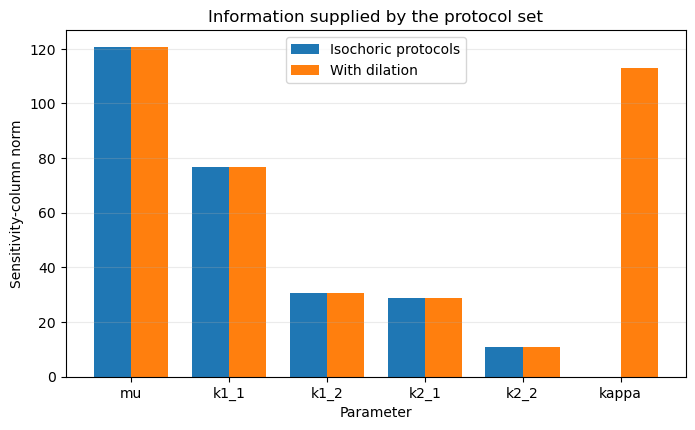

In [25]:
column_norm_isochoric = np.linalg.norm(
    weighted_log_sensitivity_isochoric,
    axis=0,
)
column_norm_augmented = np.linalg.norm(
    weighted_log_sensitivity_augmented,
    axis=0,
)

figure, axis = plt.subplots(figsize=(8, 4.5))
positions = np.arange(parameter_map.size)
width = 0.38
axis.bar(
    positions - width / 2,
    column_norm_isochoric,
    width=width,
    label="Isochoric protocols",
)
axis.bar(
    positions + width / 2,
    column_norm_augmented,
    width=width,
    label="With dilation",
)
axis.set(
    xlabel="Parameter",
    ylabel="Sensitivity-column norm",
    title="Information supplied by the protocol set",
    xticks=positions,
    xticklabels=parameter_map.parameter_names,
)
axis.grid(True, axis="y", alpha=0.25)
axis.legend()
plt.show()

The zero \(\kappa\) column is a structural property. Under \(J=1\),

\[
\ln J=0,
\]

so the volumetric stress contribution is zero for every value of
\(\kappa\). No optimizer can recover a parameter that does not affect
the observations.

## 4. Weighted nonlinear least-squares fit

In [26]:
initial_values = np.array([1.8, 2.2, 2.2, 3.8, 3.8, 120.0])
lower_bounds = np.array([0.2, 0.2, 0.2, 0.5, 0.5, 20.0])
upper_bounds = np.array([8.0, 10.0, 10.0, 12.0, 12.0, 600.0])

fit = fit_material_parameters(
    augmented_dataset,
    fiber_direction,
    structural_order,
    parameter_map,
    initial_values=initial_values,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
)

relative_error = (
    fit.parameter_vector - true_parameters
) / true_parameters

print(f"Optimizer success: {fit.success}")
print(f"Message: {fit.message}")
print(f"Function evaluations: {fit.number_of_function_evaluations}")
print(f"Weighted objective: {fit.objective:.6f}")
print(f"Degrees of freedom: {fit.degrees_of_freedom}")
print(f"Jacobian condition number: {fit.condition_number:.3e}")
print()
print(
    f"{'parameter':>12} {'truth':>12} {'estimate':>12} "
    f"{'std. error':>12} {'relative error':>16}"
)
for name, truth, estimate, standard_error, error in zip(
    fit.parameter_names,
    true_parameters,
    fit.parameter_vector,
    fit.standard_error,
    relative_error,
    strict=True,
):
    print(
        f"{name:>12} {truth:12.6f} {estimate:12.6f} "
        f"{standard_error:12.6f} {error:16.3%}"
    )

assert fit.success
assert np.all(np.isfinite(fit.parameter_vector))

Optimizer success: True
Message: `ftol` termination condition is satisfied.
Function evaluations: 8
Weighted objective: 25.458288
Degrees of freedom: 40
Jacobian condition number: 3.303e+01

   parameter        truth     estimate   std. error   relative error
          mu     2.400000     2.412172     0.039013           0.507%
        k1_1     3.200000     3.205833     0.136479           0.182%
        k1_2     1.700000     1.459756     0.165000         -14.132%
        k2_1     4.600000     4.611010     0.428748           0.239%
        k2_2     3.400000     5.155027     0.856210          51.618%
       kappa   180.000000   181.632829     1.275248           0.907%


### 4.1 Fit by loading protocol

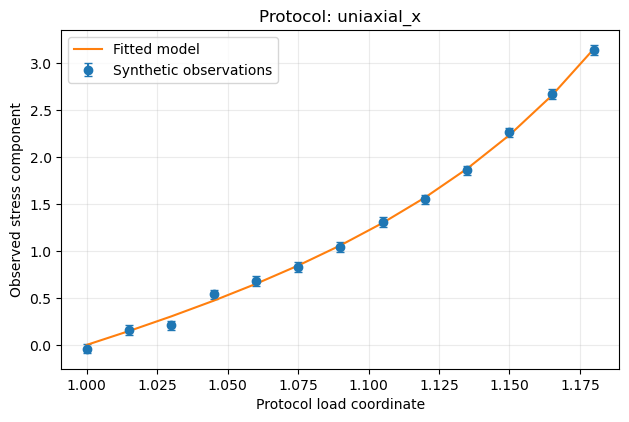

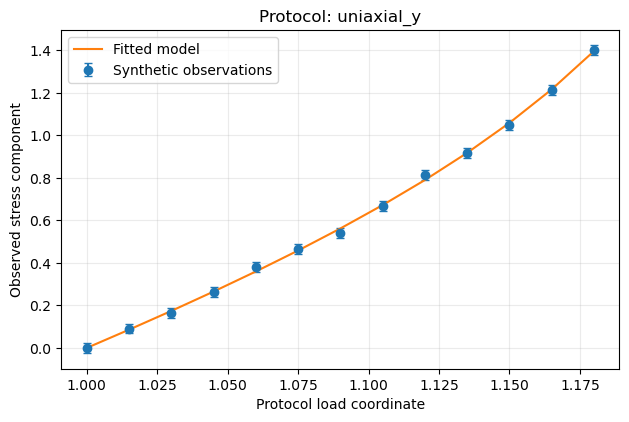

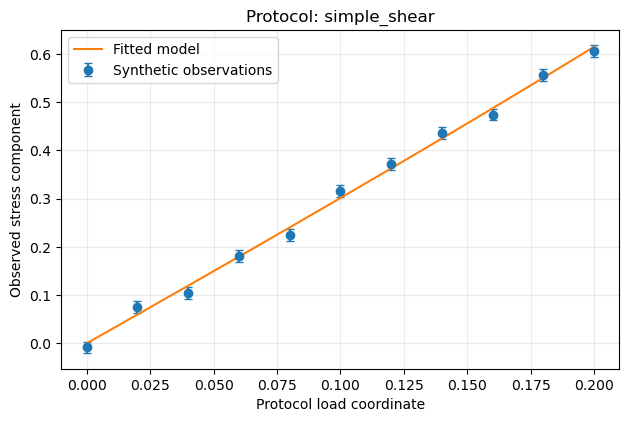

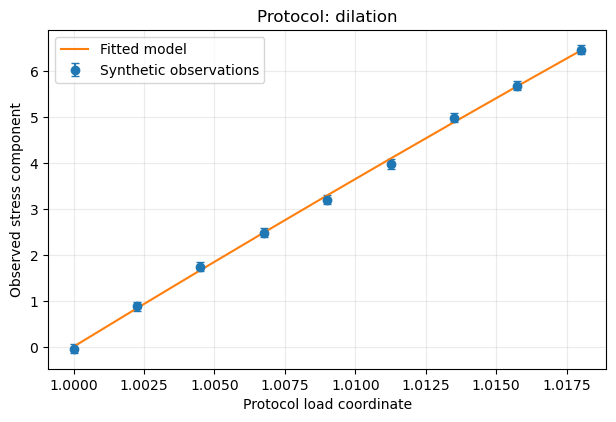

          protocol         RMSE
        uniaxial_x     0.038474
        uniaxial_y     0.011505
      simple_shear     0.011841
          dilation     0.067845


In [27]:
protocol_rmse = {}

for protocol in augmented_dataset.protocols:
    protocol_dataset = augmented_dataset.subset([protocol])
    protocol_prediction = predict_dataset_stress(
        protocol_dataset,
        fiber_direction,
        structural_order,
        fit.material,
    )
    rmse = float(
        np.sqrt(
            np.mean(
                (
                    protocol_prediction
                    - protocol_dataset.observed_stress
                )
                ** 2
            )
        )
    )
    protocol_rmse[protocol] = rmse

    figure, axis = plt.subplots(figsize=(7.2, 4.4))
    axis.errorbar(
        protocol_dataset.load_value,
        protocol_dataset.observed_stress,
        yerr=protocol_dataset.noise_std,
        fmt="o",
        capsize=3,
        label="Synthetic observations",
    )
    order = np.argsort(protocol_dataset.load_value)
    axis.plot(
        protocol_dataset.load_value[order],
        protocol_prediction[order],
        label="Fitted model",
    )
    axis.set(
        xlabel="Protocol load coordinate",
        ylabel="Observed stress component",
        title=f"Protocol: {protocol}",
    )
    axis.grid(True, alpha=0.25)
    axis.legend()
    plt.show()

print(f"{'protocol':>18} {'RMSE':>12}")
for name, value in protocol_rmse.items():
    print(f"{name:>18} {value:12.6f}")

### 4.2 Weighted residual diagnostics

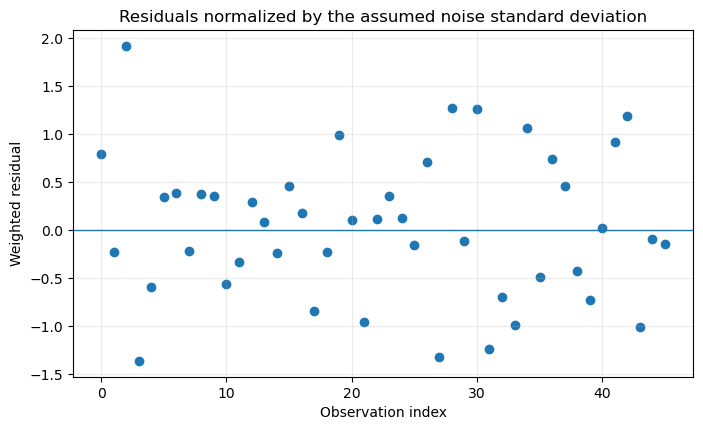

Mean weighted residual: 0.033180
Std. weighted residual: 0.751408


In [28]:
figure, axis = plt.subplots(figsize=(8, 4.5))
observation_index = np.arange(augmented_dataset.number_of_observations)
axis.axhline(0.0, linewidth=1.0)
axis.scatter(observation_index, fit.weighted_residual)
axis.set(
    xlabel="Observation index",
    ylabel="Weighted residual",
    title="Residuals normalized by the assumed noise standard deviation",
)
axis.grid(True, alpha=0.25)
plt.show()

print(f"Mean weighted residual: {np.mean(fit.weighted_residual):.6f}")
print(f"Std. weighted residual: {np.std(fit.weighted_residual, ddof=1):.6f}")

## 5. Local covariance and parameter correlation

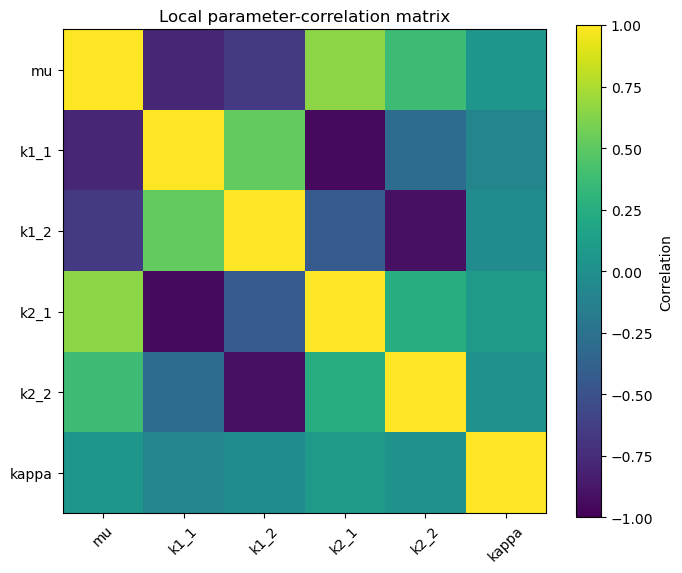

Largest absolute off-diagonal correlation: -0.945790 between k2_1 and k1_1


In [29]:
figure, axis = plt.subplots(figsize=(7.0, 5.8))
image = axis.imshow(fit.correlation, vmin=-1.0, vmax=1.0)
axis.set(
    title="Local parameter-correlation matrix",
    xticks=np.arange(parameter_map.size),
    yticks=np.arange(parameter_map.size),
    xticklabels=fit.parameter_names,
    yticklabels=fit.parameter_names,
)
axis.tick_params(axis="x", rotation=45)
figure.colorbar(image, ax=axis, label="Correlation")
figure.tight_layout()
plt.show()

off_diagonal = fit.correlation - np.eye(parameter_map.size)
maximum_correlation_index = np.unravel_index(
    np.argmax(np.abs(off_diagonal)),
    off_diagonal.shape,
)
print(
    "Largest absolute off-diagonal correlation: "
    f"{off_diagonal[maximum_correlation_index]:.6f} between "
    f"{fit.parameter_names[maximum_correlation_index[0]]} and "
    f"{fit.parameter_names[maximum_correlation_index[1]]}"
)

Strong parameter correlations indicate that accurate curve fitting
does not automatically imply independent parameter determination.
The local covariance is conditional on the Gaussian noise model and
linearization around the optimum.

## 6. Parametric-bootstrap uncertainty

In [30]:
bootstrap = parametric_bootstrap_material_fit(
    augmented_dataset,
    fiber_direction,
    structural_order,
    parameter_map,
    fit,
    lower_bounds=lower_bounds,
    upper_bounds=upper_bounds,
    number_of_samples=100,
    random_seed=2026,
)

bootstrap_lower, bootstrap_upper = bootstrap.percentile_interval()
bootstrap_samples = bootstrap.successful_samples
coverage = (
    (true_parameters >= bootstrap_lower)
    & (true_parameters <= bootstrap_upper)
)

print(f"Successful bootstrap fits: {bootstrap_samples.shape[0]} / 100")
print(
    f"{'parameter':>12} {'estimate':>12} {'2.5%':>12} "
    f"{'97.5%':>12} {'truth covered':>15}"
)
for name, estimate, lower, upper, covered in zip(
    fit.parameter_names,
    fit.parameter_vector,
    bootstrap_lower,
    bootstrap_upper,
    coverage,
    strict=True,
):
    print(
        f"{name:>12} {estimate:12.6f} {lower:12.6f} "
        f"{upper:12.6f} {str(bool(covered)):>15}"
    )

assert bootstrap_samples.shape[0] == 100
assert np.all(coverage)

Successful bootstrap fits: 100 / 100
   parameter     estimate         2.5%        97.5%   truth covered
          mu     2.412172     2.311925     2.497231            True
        k1_1     3.205833     2.934318     3.611342            True
        k1_2     1.459756     1.120373     1.901474            True
        k2_1     4.611010     3.515201     5.505340            True
        k2_2     5.155027     3.320014     7.419289            True
       kappa   181.632829   178.568855   184.838686            True


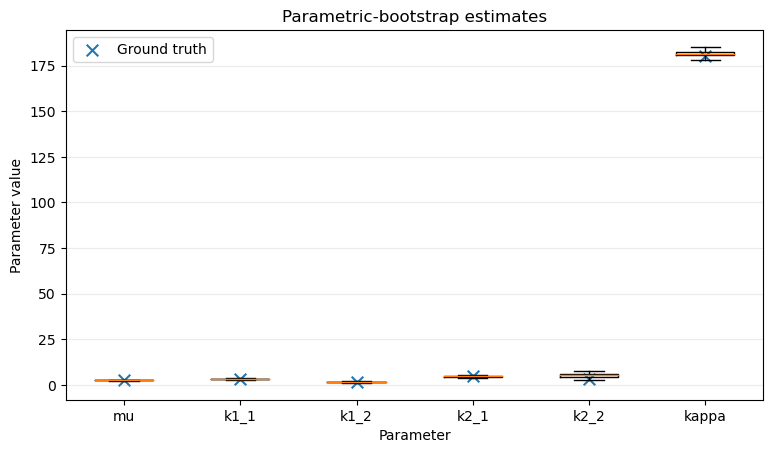

In [33]:
figure, axis = plt.subplots(figsize=(9, 4.8))
axis.boxplot(
    [bootstrap_samples[:, index] for index in range(parameter_map.size)],
    labels=fit.parameter_names,          # ← fixed here
    showfliers=False,
)
axis.scatter(
    np.arange(1, parameter_map.size + 1),
    true_parameters,
    marker="x",
    s=70,
    label="Ground truth",
)
axis.set(
    xlabel="Parameter",
    ylabel="Parameter value",
    title="Parametric-bootstrap estimates",
)
axis.grid(True, axis="y", alpha=0.25)
axis.legend()
plt.show()

### 6.1 Predictive interval for axial extension

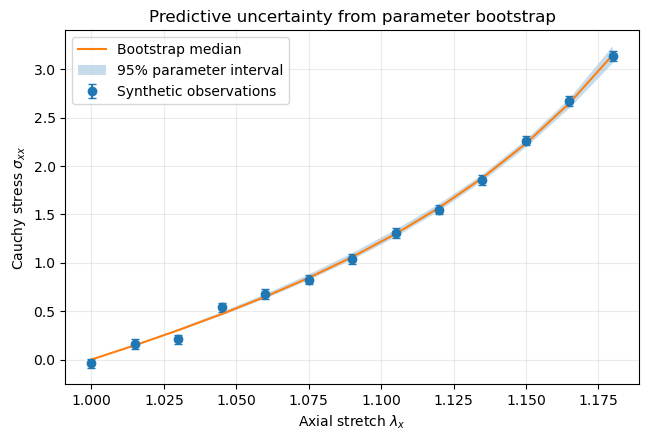

In [34]:
axial_x_dataset = augmented_dataset.subset(["uniaxial_x"])
bootstrap_prediction = np.empty(
    (
        bootstrap_samples.shape[0],
        axial_x_dataset.number_of_observations,
    )
)

for sample_index, parameter_sample in enumerate(bootstrap_samples):
    bootstrap_material = parameter_map.unpack(parameter_sample)
    bootstrap_prediction[sample_index] = predict_dataset_stress(
        axial_x_dataset,
        fiber_direction,
        structural_order,
        bootstrap_material,
    )

prediction_lower = np.percentile(bootstrap_prediction, 2.5, axis=0)
prediction_median = np.percentile(bootstrap_prediction, 50.0, axis=0)
prediction_upper = np.percentile(bootstrap_prediction, 97.5, axis=0)
order = np.argsort(axial_x_dataset.load_value)

figure, axis = plt.subplots(figsize=(7.4, 4.6))
axis.errorbar(
    axial_x_dataset.load_value,
    axial_x_dataset.observed_stress,
    yerr=axial_x_dataset.noise_std,
    fmt="o",
    capsize=3,
    label="Synthetic observations",
)
axis.plot(
    axial_x_dataset.load_value[order],
    prediction_median[order],
    label="Bootstrap median",
)
axis.fill_between(
    axial_x_dataset.load_value[order],
    prediction_lower[order],
    prediction_upper[order],
    alpha=0.25,
    label="95% parameter interval",
)
axis.set(
    xlabel=r"Axial stretch $\lambda_x$",
    ylabel=r"Cauchy stress $\sigma_{xx}$",
    title="Predictive uncertainty from parameter bootstrap",
)
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

## 7. Export reproducible inverse-problem results

In [35]:
output_data = REPOSITORY_ROOT / "results" / "data"
output_figures = REPOSITORY_ROOT / "results" / "figures"
output_data.mkdir(parents=True, exist_ok=True)
output_figures.mkdir(parents=True, exist_ok=True)

observations_path = output_data / "parameter_identification_observations.csv"
with observations_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "protocol",
            "load_value",
            "F_11",
            "F_12",
            "F_21",
            "F_22",
            "stress_row",
            "stress_column",
            "observed_stress",
            "noise_std",
            "fitted_stress",
        ]
    )
    for index in range(augmented_dataset.number_of_observations):
        writer.writerow(
            [
                augmented_dataset.protocol_name[index],
                augmented_dataset.load_value[index],
                *augmented_dataset.deformation_gradient[index].ravel(),
                *augmented_dataset.stress_component[index],
                augmented_dataset.observed_stress[index],
                augmented_dataset.noise_std[index],
                fit.predicted_stress[index],
            ]
        )

estimates_path = output_data / "parameter_identification_estimates.csv"
with estimates_path.open("w", newline="", encoding="utf-8") as stream:
    writer = csv.writer(stream)
    writer.writerow(
        [
            "parameter",
            "truth",
            "estimate",
            "standard_error",
            "bootstrap_lower_95",
            "bootstrap_upper_95",
        ]
    )
    for row in zip(
        fit.parameter_names,
        true_parameters,
        fit.parameter_vector,
        fit.standard_error,
        bootstrap_lower,
        bootstrap_upper,
        strict=True,
    ):
        writer.writerow(row)

bootstrap_path = output_data / "parameter_identification_bootstrap.csv"
np.savetxt(
    bootstrap_path,
    bootstrap_samples,
    delimiter=",",
    header=",".join(fit.parameter_names),
    comments="",
)

sensitivity_path = output_data / "parameter_identification_sensitivity.npz"
np.savez_compressed(
    sensitivity_path,
    parameter_names=np.asarray(fit.parameter_names),
    sensitivity_isochoric=sensitivity_isochoric,
    sensitivity_augmented=sensitivity_augmented,
    weighted_log_sensitivity_isochoric=weighted_log_sensitivity_isochoric,
    weighted_log_sensitivity_augmented=weighted_log_sensitivity_augmented,
    singular_values_isochoric=singular_isochoric,
    singular_values_augmented=singular_augmented,
    covariance=fit.covariance,
    correlation=fit.correlation,
)

summary_path = output_figures / "parameter_identification_summary.png"
figure, axis = plt.subplots(figsize=(9, 4.8))
positions = np.arange(parameter_map.size)
error_lower = fit.parameter_vector - bootstrap_lower
error_upper = bootstrap_upper - fit.parameter_vector
axis.errorbar(
    positions,
    fit.parameter_vector,
    yerr=np.vstack((error_lower, error_upper)),
    fmt="o",
    capsize=4,
    label="Estimate and bootstrap 95% interval",
)
axis.scatter(
    positions,
    true_parameters,
    marker="x",
    s=70,
    label="Ground truth",
)
axis.set(
    xlabel="Parameter",
    ylabel="Parameter value",
    title="Recovered constitutive parameters",
    xticks=positions,
    xticklabels=fit.parameter_names,
)
axis.grid(True, axis="y", alpha=0.25)
axis.legend()
figure.tight_layout()
figure.savefig(summary_path, dpi=180)
plt.close(figure)

print(f"Saved: {observations_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {estimates_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {bootstrap_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {sensitivity_path.relative_to(REPOSITORY_ROOT)}")
print(f"Saved: {summary_path.relative_to(REPOSITORY_ROOT)}")

Saved: results\data\parameter_identification_observations.csv
Saved: results\data\parameter_identification_estimates.csv
Saved: results\data\parameter_identification_bootstrap.csv
Saved: results\data\parameter_identification_sensitivity.npz
Saved: results\figures\parameter_identification_summary.png


## 8. Final checks and interpretation

In [36]:
checks = {
    "isochoric design is rank deficient": rank_isochoric == 5,
    "dilation restores full rank": rank_augmented == 6,
    "optimizer converged": fit.success,
    "all fitted parameters are positive": np.all(fit.parameter_vector > 0.0),
    "all bootstrap fits succeeded": bootstrap_samples.shape[0] == 100,
    "all truths lie in bootstrap intervals": np.all(coverage),
    "finite covariance": np.all(np.isfinite(fit.covariance)),
    "finite predictions": np.all(np.isfinite(fit.predicted_stress)),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")
assert all(checks.values())

PASS — isochoric design is rank deficient
PASS — dilation restores full rank
PASS — optimizer converged
PASS — all fitted parameters are positive
PASS — all bootstrap fits succeeded
PASS — all truths lie in bootstrap intervals
PASS — finite covariance
PASS — finite predictions


## Interpretation

The augmented protocol set recovers all six synthetic parameters
with finite local covariance and complete bootstrap coverage.
However, the correlation matrix shows that some fiber parameters
remain strongly coupled. Therefore, a visually accurate stress fit
should not be interpreted as proof that every constitutive
parameter is independently determined.

The uncertainty intervals are conditional on:

- the selected constitutive model;
- known fiber directions, structural order, and mixture weights;
- independent Gaussian observation errors;
- the selected parameter bounds;
- the chosen loading protocols.

They do not include image-reconstruction uncertainty, specimen
variability, model discrepancy, or experimental systematics.
